# Notebook 5: The Full Pipeline — Training GeoTransolver on the Ahmed Body

---

## Where we are in the series

| Notebook | Topic |
|---|---|
| NB1 | Why standard Transformers fail at large meshes ($O(N^2)$) |
| NB2 | How Transolver fixes it: Physics-Attention ($O(N)$) |
| NB3 | Training Transolver on the Ahmed Body |
| NB4 | How GeoTransolver extends Transolver with GALE geometry injection |
| **NB5** | **Training GeoTransolver — same pipeline, same data, richer model** |

### What is the same as Notebook 3?
- **Zarr dataset** — identical files, no re-preprocessing.
- **Data pipeline** — `CAEDataset` + `TransolverDataPipe` (same classes, different config).
- **Normalization file** — same `surface_fields_normalization.npz`.
- **Training loop structure** — same epoch/val/checkpoint pattern.

### What is different?
- **Model** — `GeoTransolver` instead of `Transolver` (GALE cross-attention at every layer).
- **`broadcast_global_features=False`** — global flow conditions passed as a separate
  `global_embedding` rather than broadcast to every point.
- **`include_geometry=True`** — datapipe also returns `batch["geometry"]` (STL coordinates)
  for GALE cross-attention.
- **Forward call** — `model(global_embedding=..., local_embedding=..., geometry=..., local_positions=...)`

---

## Before you run: the pretrained checkpoint, and fitting this to your GPU

### Where the numbers in this notebook come from

Every figure and metric below was produced by **resuming from a pretrained
GeoTransolver checkpoint**, not by training from scratch. Training this model to
convergence takes many hundreds of epochs on multiple GPUs — far beyond a
notebook session. So the model hyperparameters in Section 2 are set to **match
the architecture of that pretrained checkpoint**, because a checkpoint can only
be loaded into a model with identical layer shapes.

The notebook then runs a short continuation (a few epochs) on top of it. That is
enough to watch the training loop work end to end and to produce meaningful
slice and uncertainty visualisations, without pretending you have retrained the
model yourself.

### You can change the hyperparameters — but know what you are giving up

Nothing forces you to keep these values. If the model does not fit in your GPU,
**change them.** The one consequence to understand:

> Changing a parameter that alters a **layer shape** means the pretrained
> checkpoint can no longer be loaded. The notebook will start from random
> weights, still run correctly, but the loss will be high and the Section 8/9
> visualisations will show an untrained model.

That split — shape-safe versus shape-changing — is what Section 2 walks through,
along with which knobs buy the most memory per unit of accuracy lost. If you are
memory constrained, the short version is: **reduce `NUM_POINTS` first.** It is
the only large lever that costs you nothing structurally.


---
## 1. Imports

The imports are nearly identical to Notebook 3. The two key changes are:

1. **`GeoTransolver`** instead of `Transolver` — lives in the experimental namespace:  
   `physicsnemo.experimental.models.geotransolver.GeoTransolver`

2. **Same `TransolverDataPipe` / `CAEDataset`** — the pipeline classes are reused unchanged.  
   The difference is the *configuration* passed to `TransolverDataPipe`, not the class itself.

### `broadcast_global_features` — the critical switch

This one flag is what separates the Transolver and GeoTransolver data pipelines:

```
Transolver  (NB3):  broadcast_global_features = True
  Why: Transolver has no separate global-conditioning pathway.
       The only way flow conditions reach the model is if they are
       copied into every mesh point's feature vector.
       batch["fx"].shape = (1, N, 2)  ← 2 scalars × N points

GeoTransolver (NB5): broadcast_global_features = False
  Why: GALE re-injects geometry context at *every* transformer layer.
       Global flow conditions are passed as a dedicated global_embedding
       argument — separate from the per-point local geometry.
       batch["fx"].shape = (1, 1, 2)  ← 2 scalars, NOT repeated per-point
```

### Model selection via YAML config

In the production `transformer_models/src` workflow, Hydra selects the model class via:

```yaml
# conf/model/transolver.yaml
_target_: physicsnemo.models.transolver.Transolver
functional_dim: 2      ← fx:  air_density + stream_velocity (broadcast)
embedding_dim:  6      ← embedding: coords(3) + normals(3)
out_dim:        4

# conf/model/geotransolver.yaml
_target_: physicsnemo.experimental.models.geotransolver.GeoTransolver
functional_dim: 6      ← local_embedding:  coords(3) + normals(3)
global_dim:     2      ← global_embedding: air_density + stream_velocity
geometry_dim:   3      ← geometry:         STL coordinates (for GALE)
out_dim:        4
```

Notice how the **same data fields** map to **different model arguments**:
- In Transolver, `air_density + velocity` are part of `fx` (broadcast to N points).
- In GeoTransolver, `coords + normals` are the local functional input `local_embedding`,
  and `air_density + velocity` are passed as a *separate* `global_embedding`.

In [11]:
import os
import random
import time
from pathlib import Path
from contextlib import nullcontext

# Core ML / Data Libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from tabulate import tabulate
import torchinfo

# Visualization
import pyvista as pv
from tqdm import tqdm
from IPython.display import Markdown as md, display
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── PhysicsNeMo Imports ────────────────────────────────────────────────────────
try:
    # GeoTransolver lives in the 'experimental' namespace
    from physicsnemo.experimental.models.geotransolver import GeoTransolver

    from physicsnemo.distributed import DistributedManager
    from physicsnemo.utils.logging import PythonLogger          # updated path

    # Same pipeline classes as Notebook 3 — different configuration, same API
    from physicsnemo.datapipes.cae.transolver_datapipe import TransolverDataPipe
    from physicsnemo.datapipes.cae.cae_dataset import CAEDataset

    print("✓ All imports successful.")
except ImportError as e:
    print("=" * 60)
    print("ERROR: Could not import PhysicsNeMo or utility files.")
    print("  1. physicsnemo installed with experimental support?")
    print("  2. Correct version with GeoTransolver?")
    print(f"Details: {e}")
    print("=" * 60)
    raise

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)
random.seed(42)

# Headless PyVista setup
os.environ.setdefault("XDG_RUNTIME_DIR", "/tmp")
os.environ.setdefault("PYVISTA_OFF_SCREEN", "true")

try:
    # Newer PyVista versions may not expose start_xvfb at the top level
    try:
        pv.start_xvfb()
    except AttributeError:
        from pyvista.plotting.utilities.xvfb import start_xvfb
        start_xvfb()

    print("✓ Xvfb started.")
except Exception as e:
    print(f"Warning: Could not start Xvfb: {e}")
    print("Continuing with PyVista off-screen rendering.")

pv.OFF_SCREEN = True

print("✓ Headless PyVista configured.")

✓ All imports successful.
Continuing with PyVista off-screen rendering.
✓ Headless PyVista configured.


---
## 2. Configuration

This cell defines the model dimensions, paths, and training hyperparameters.

### Why these particular values?

The results in this notebook were generated by continuing from a **pretrained
GeoTransolver checkpoint**. PyTorch can only load a checkpoint into a model whose
layer shapes match exactly, so the architecture values below are chosen to match
that pretrained model:

| Parameter | Value | Role |
|---|---|---|
| `functional_dim` | 6 | `local_embedding` = coords(3) + normals(3) |
| `global_dim` | 2 | `global_embedding` = air_density + stream_velocity |
| `geometry_dim` | 3 | `geometry` = STL vertex coordinates (GALE input) |
| `out_dim` | 4 | pressure(1) + WSS x,y,z(3) |
| `n_hidden` | 256 | → `C_MODEL` |
| `n_layers` | 20 | → `NUM_LAYERS` |
| `n_head` | 8 | → `NUM_HEADS` |
| `slice_num` | 128 | → `M_SLICES` |
| `mlp_ratio` | 2 | MLP expansion inside each block |

A note on one easily-confused number: the **block hidden dimension is not
`n_hidden`**. It is

$$
d_{\text{block}} \;=\; n_{\text{hidden}} \;+\; n_{\text{radii}} \times n_{\text{hidden local}}
\;=\; 256 + 4 \times 32 \;=\; 384
$$

because the local-feature channels are concatenated onto the hidden state before
the blocks. If you see 384 in a shape-mismatch error, that is `d_block`, and
`n_hidden` is still 256.

---

### Reducing memory: which knob to turn first

You are free to change any of these to fit your GPU. The knobs fall into two
groups, and the distinction matters more than any individual value.

#### Group 1 — shape-safe (pretrained checkpoint still loads)

These change how much data flows through the model, not what the model *is*:

| Knob | Memory scaling | Cost of reducing it |
|---|---|---|
| **`NUM_POINTS`** | **linear** — dominates activation memory | Coarser surface sampling. **Start here.** |
| `PRECISION` → `"bfloat16"` | ~2x on activations | Slight numerical noise; usually negligible |
| `geometry_sampling` | linear in the GALE context length | Coarser geometry for cross-attention |
| `neighbors_in_radius` | linear in `sum(neighbors)` | Shapes still match, but the *computation* changes, so expect accuracy drift |

#### Group 2 — shape-changing (checkpoint will **not** load; requires retraining)

| Knob | Memory scaling | Note |
|---|---|---|
| `NUM_LAYERS` | linear in both activations and parameters | Largest structural saving |
| `C_MODEL` | **quadratic** in parameters, linear in activations | Biggest parameter saving |
| `MLP_RATIO` | linear in the MLP's hidden width | Cheap accuracy-wise, modest saving |
| `M_SLICES` | linear in the slice-projection tensor | Also changes the Section 8/9 analysis |
| `n_hidden_local`, `radii` | changes `d_block`, so every block resizes | Avoid unless retraining anyway |

#### The recommended order

1. **`NUM_POINTS`** — halving it roughly halves activation memory, keeps the
   checkpoint valid, and costs only surface resolution. Nothing else combines
   that much saving with that little consequence.
2. **`PRECISION = "bfloat16"`** — another ~2x, still checkpoint-safe.
3. **`neighbors_in_radius`** — the local-feature gather materialises a tensor of
   roughly `NUM_POINTS x sum(neighbors) x n_hidden_local`, and with
   `[8, 16, 64, 128]` that sum is **216 taps per point**, often the single
   largest allocation in the model. Trimming the two coarse scales (e.g. to
   `[8, 16, 32, 32]`, i.e. 88 taps) cuts it by ~2.5x while keeping shapes valid.
4. Only if all of that is insufficient, reduce **`NUM_LAYERS`** — and accept
   that you are now training from scratch.

> **Rule of thumb:** exhaust Group 1 before touching Group 2. Group 1 costs you
> resolution; Group 2 costs you the pretrained model.

> **Prerequisite:** Run **Notebook 0** first — it writes the Zarr stores and the
> normalization file that NB3 and NB5 share.

In [15]:
# ── 1. Data Paths (written by Notebook 0) ────────────────────────────────────
# EDIT FOR YOUR MACHINE, or set ZARR_DIR. Matches NB3/NB6.
# NOTE: this must be the dataset the checkpoint you resume from was TRAINED on —
# the target-scale guard in Section 5 checks that and refuses to proceed if not.
ZARR_OUTPUT_DIR = os.environ.get(
    "ZARR_DIR",
    "/workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr")

TRAIN_ZARR_DIR = os.path.join(ZARR_OUTPUT_DIR, "train")
VAL_ZARR_DIR   = os.path.join(ZARR_OUTPUT_DIR, "validation")

# Normalization file produced by Notebook 0 (shared with Notebook 3)
NORM_FILE = os.path.join(ZARR_OUTPUT_DIR, "surface_fields_normalization.npz")

# ── 2. Output paths ───────────────────────────────────────────────────────────
CHECKPOINT_DIR = "./checkpoints_geotransolver/"
LOG_DIR        = "./logs_geotransolver/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(LOG_DIR, exist_ok=True)

# ── 3. Fixed problem dimensions (set by the dataset, not tunable) ─────────────
FUNCTIONAL_DIM = 6   # local_embedding:  coords(3) + normals(3)
GLOBAL_DIM     = 2   # global_embedding: air_density + stream_velocity (via GALE)
GEOMETRY_DIM   = 3   # geometry:         STL vertex coordinates for GALE cross-attention
OUT_DIM        = 4   # output:           pressure(1) + WSS x,y,z(3)

# ── 4. Model architecture ─────────────────────────────────────────────────────
# The results in this notebook were produced by continuing from a PRETRAINED
# GeoTransolver checkpoint.  A checkpoint only loads into a model with matching
# layer shapes, so the values below are chosen to match that pretrained model.
#
# You may change them. Everything in block 4 below alters a LAYER SHAPE, so the
# pretrained checkpoint will no longer load and training restarts from random
# weights.  See Section 2's markdown for the memory/accuracy trade-offs.
C_MODEL    = 256   # n_hidden.  NOTE: the BLOCK dim is n_hidden + n_radii*n_hidden_local
                   #            = 256 + 4*32 = 384.  A "384" in a shape error is d_block.
MLP_RATIO  = 2     # MLP inside each block expands d_block 384 -> 768 -> 384
M_SLICES   = 128   # slice_num — also sets the x-axis of the Section 8/9 analysis
NUM_LAYERS = 20    # n_layers
NUM_HEADS  = 8     # n_head

# Local-feature extraction.  radii / n_hidden_local change d_block, so they are
# shape-changing.  neighbors_in_radius does NOT change any weight shape — it is
# a memory knob (see below) — but it does change the computation, so results
# will drift from the pretrained model's.
RADII               = [0.01, 0.05, 0.25, 1.0]
NEIGHBORS_IN_RADIUS = [8, 16, 64, 128]
N_HIDDEN_LOCAL      = 32

# ── 5. Run settings (shape-safe: checkpoint still loads if you change these) ──
NUM_EPOCHS    = 1          # short continuation on top of the pretrained weights
LEARNING_RATE = 1e-4
PRECISION     = "float32"  # "bfloat16" roughly halves activation memory

# NUM_POINTS is the single most effective memory knob: activation memory is
# LINEAR in it, and reducing it costs only surface sampling resolution — no
# layer shape changes, so the pretrained checkpoint still loads.
# Reduce THIS first if you hit OOM.
NUM_POINTS = 10_000        # surface points subsampled per sample (-1 = full mesh)

# Per-axis coordinate scaling. MUST match the pretrained checkpoint:
# train_v1_p2.log -> scale_invariance: true, reference_scale: [1.35, 0.26, 0.44].
# This is SHAPE-SAFE (no layer changes) but changing it silently invalidates the
# checkpoint, because the ball-query RADII above are radii in this scaled frame.
REFERENCE_SCALE = [1.35, 0.26, 0.44]

# ── 6. Derived quantities + relative memory indicator ─────────────────────────
D_BLOCK       = C_MODEL + len(RADII) * N_HIDDEN_LOCAL
NEIGHBOR_TAPS = sum(NEIGHBORS_IN_RADIUS)

# Two dominant allocations, in arbitrary units so you can compare BEFORE/AFTER
# a config change.  These are relative indices, not byte counts.
act_index   = NUM_POINTS * D_BLOCK * NUM_LAYERS / 1e9
local_index = NUM_POINTS * NEIGHBOR_TAPS * N_HIDDEN_LOCAL / 1e9

print("=" * 62)
print("GeoTransolver Configuration")
print("=" * 62)
print(f"  Train Zarr     : {TRAIN_ZARR_DIR}")
print(f"  Val   Zarr     : {VAL_ZARR_DIR}")
print(f"  Norm  file     : {NORM_FILE}")
print("-" * 62)
print(f"  functional_dim : {FUNCTIONAL_DIM}   global_dim: {GLOBAL_DIM}   "
      f"geometry_dim: {GEOMETRY_DIM}   out_dim: {OUT_DIM}")
print(f"  n_hidden       : {C_MODEL}   mlp_ratio: {MLP_RATIO}   slice_num: {M_SLICES}")
print(f"  n_layers       : {NUM_LAYERS}    n_head: {NUM_HEADS}")
print(f"  d_block        : {D_BLOCK}  = {C_MODEL} + {len(RADII)}x{N_HIDDEN_LOCAL}")
print(f"  neighbour taps : {NEIGHBOR_TAPS}  per point  {NEIGHBORS_IN_RADIUS}")
print("-" * 62)
print(f"  NUM_POINTS     : {NUM_POINTS:,}   precision: {PRECISION}")
print(f"  relative memory index (lower = less memory):")
print(f"     block activations : {act_index:7.2f}   ~ NUM_POINTS x d_block x n_layers")
print(f"     local-feature gather: {local_index:6.2f}   ~ NUM_POINTS x taps x n_hidden_local")
print(f"  If you OOM: halve NUM_POINTS first (both indices halve, shapes unchanged).")
print("=" * 62)


GeoTransolver Configuration
  Train Zarr     : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/train
  Val   Zarr     : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/validation
  Norm  file     : /workspace/physicsnemo_ahmed_body_dataset_vv1/dataset/ahmed_body_zarr/surface_fields_normalization.npz
--------------------------------------------------------------
  functional_dim : 6   global_dim: 2   geometry_dim: 3   out_dim: 4
  n_hidden       : 256   mlp_ratio: 2   slice_num: 128
  n_layers       : 20    n_head: 8
  d_block        : 384  = 256 + 4x32
  neighbour taps : 216  per point  [8, 16, 64, 128]
--------------------------------------------------------------
  NUM_POINTS     : 10,000   precision: float32
  relative memory index (lower = less memory):
     block activations :    0.08   ~ NUM_POINTS x d_block x n_layers
     local-feature gather:   0.07   ~ NUM_POINTS x taps x n_hidden_local
  If you OOM: halve NUM_POINTS first (both ind

---
## 3. Data Verification

GeoTransolver uses the **exact same Zarr files** created in Notebook 3. We simply verify they exist before proceeding.

If the check fails, go back to Notebook 0 (Data Preprocessing) and run it first.


In [16]:
# ── Verify Zarr data exists ──────────────────────────────────────────────
train_zarr_files = sorted(Path(TRAIN_ZARR_DIR).glob("*.zarr")) if Path(TRAIN_ZARR_DIR).exists() else []
val_zarr_files   = sorted(Path(VAL_ZARR_DIR).glob("*.zarr"))   if Path(VAL_ZARR_DIR).exists() else []

print(f"Training samples   : {len(train_zarr_files)}")
print(f"Validation samples : {len(val_zarr_files)}")

if len(train_zarr_files) == 0 or len(val_zarr_files) == 0:
    raise FileNotFoundError(
        "No Zarr files found.\n"
        "Please run Notebook 0 (Data Preprocessing) first to generate the dataset."
    )

print("✓ Dataset verified.")


Training samples   : 408
Validation samples : 50
✓ Dataset verified.


---
## 4. Normalization

GeoTransolver predicts the **same 4 output channels** as Transolver (pressure + WSS),
so it uses the **exact same normalization file** produced by **Notebook 0**:

```
ahmed_body_zarr/surface_fields_normalization.npz  ←  NORM_FILE (shared with NB3)
```

> **If the file is missing**, run Notebook 0 first.  
> Never recompute normalization statistics inside a training notebook — computing them  
> on the validation split would leak information and make validation metrics misleading.


In [17]:
import socket
def get_free_port():
    """Finds an unused port on the local system."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        s.bind(('', 0))
        return str(s.getsockname()[1])

# ── Load normalization factors produced by Notebook 0 ────────────────────────
print("--- LOADING NORMALIZATION ---")

free_port = get_free_port()

# Single-process distributed setup + NCCL warnings suppressor
os.environ.update({
    "RANK": "0", 
    "WORLD_SIZE": "1",
    "MASTER_ADDR": "localhost", 
    "MASTER_PORT": free_port,
    "LOCAL_RANK": "0",
    
    # Bypasses network scanning for single-GPU setups
    "NCCL_IB_DISABLE": "1",          # Disable InfiniBand scanning
    "NCCL_SOCKET_IFNAME": "lo",      # Force NCCL to use local loopback only
    "NCCL_DEBUG": "ERROR"            # Hide non-critical warning logs
})

if not DistributedManager.is_initialized():
    DistributedManager.initialize()
dm = DistributedManager()
device = dm.device
print(f"Device: {device}")

norm_data = np.load(NORM_FILE)
norm_factors = {
    "mean": torch.from_numpy(norm_data["mean"]).to(device),
    "std":  torch.from_numpy(norm_data["std"]).to(device),
}

# Which convention is this normalization file in? Detect it rather than assume.
# Notebook 0's current code writes non-dimensional Cp/Cf (pressure std ~0.16).
# Older stores — including the one the pretrained checkpoint was trained on —
# hold RAW kinematic fields (pressure std ~342). Labelling the second set "Cp"
# would be wrong by ~2000x, so the label follows the data.
_pstd = float(norm_data["std"][0])
if _pstd > 10.0:
    channel_names = ["p (kinematic)", "tau_x", "tau_y", "tau_z"]
    _units = "raw kinematic (m^2/s^2) — NOT yet non-dimensionalised"
else:
    channel_names = ["Cp", "Cf_x", "Cf_y", "Cf_z"]
    _units = "non-dimensional coefficients (divided by q = 0.5*U^2)"
print(f"Field convention detected: {_units}")
print("\nNormalization factors (surface_fields):")
for j, name in enumerate(channel_names):
    print(f"  {name:12s}  mean={norm_factors['mean'][j].item():9.4f}  "
          f"std={norm_factors['std'][j].item():.4f}")
print("--- NORMALIZATION LOADED ---")

--- LOADING NORMALIZATION ---
Device: cuda:0
Field convention detected: raw kinematic (m^2/s^2) — NOT yet non-dimensionalised

Normalization factors (surface_fields):
  p (kinematic)  mean=-172.2178  std=341.5861
  tau_x         mean=  -2.4030  std=2.0543
  tau_y         mean=  -0.2184  std=0.8891
  tau_z         mean=  -0.0524  std=0.9628
--- NORMALIZATION LOADED ---


---
## 5. Dataset Setup and GeoTransolver Instantiation

### Why the same `TransolverDataPipe`, different config?

```
Notebook 3 (Transolver)            Notebook 5 (GeoTransolver)
─────────────────────────────────  ──────────────────────────────────────────
make_datapipe(                     make_datapipe_geo(
  broadcast_global_features=True,    broadcast_global_features=False,
  include_geometry=False,            include_geometry=True,
)                                  )

batch["fx"]         (1, N, 2)      batch["fx"]         (1, 1, 2)   ← NOT broadcast
batch["embeddings"] (1, N, 6)      batch["embeddings"] (1, N, 6)
batch["fields"]     (1, N, 4)      batch["fields"]     (1, N, 4)
                                   batch["geometry"]   (1, M, 3)   ← NEW: GALE input

forward call:                      forward call:
  model(                             model(
    fx=batch["fx"],                    global_embedding=batch["fx"],
    embedding=batch["embeddings"],     local_embedding=batch["embeddings"],
  )                                    geometry=batch["geometry"],
                                       local_positions=batch["embeddings"][:,:,:3],
                                     )
```

### GeoTransolver dimensions (from `conf/model/geotransolver.yaml`)

```yaml
functional_dim: 6    # local_embedding dimension  = coords(3) + normals(3)
global_dim:     2    # global_embedding dimension = air_density + stream_velocity
geometry_dim:   3    # geometry dimension         = STL vertex x,y,z
out_dim:        4    # output: pressure(1) + WSS(3)
```

In the production script (`train.py`), the model path switches on
`"geometry" in batch.keys()`:
```python
if "geometry" in batch.keys():       # ← GeoTransolver / Typhon path
    outputs = model(
        global_embedding=features,
        local_embedding=embeddings,
        geometry=geometry,
        local_positions=local_positions,
    )
else:                                 # ← Transolver path
    outputs = model(fx=features, embedding=embeddings)
```

`TransolverDataPipe(include_geometry=True)` adds `"geometry"` to the batch —
that single flag is what routes data to GeoTransolver vs. Transolver in production.

In [18]:
# ── Load normalization factors ──────────────────────────────────────────────
norm_data    = np.load(NORM_FILE)
norm_factors = {
    "mean": torch.from_numpy(norm_data["mean"]).to(device),
    "std":  torch.from_numpy(norm_data["std"]).to(device),
}
print("Loaded normalization factors.")

# ── Keys to read from Zarr (same files as Notebook 3) ───────────────────────
# stl_coordinates was saved by Notebook 0's preprocessing and is needed here
# for the GALE geometry tensor.
# batch["fx"] is built by TransolverDataPipe as
#     fx = torch.stack([air_density, stream_velocity], dim=-1)
# i.e. the RAW scalars, in that order, with no reference division anywhere. The
# strings global_params_values / global_params_reference do not appear in the
# datapipe at all — which is why they are commented out of DATA_KEYS below.
# For GeoTransolver broadcast_global_features=False → fx stays (1,1,2), not expanded.
DATA_KEYS = [
    'surface_mesh_centers', 'surface_normals', 'surface_fields',
    'stl_coordinates',   # STL vertices — GALE geometry input
    'stl_centers',
#    'global_params_values', 'global_params_reference',  # DoMINO convention
    'air_density', 'stream_velocity',                   # TransolverDataPipe builds batch["fx"] from these
]

# NUM_POINTS is defined once in the Configuration cell (Section 2).
# It used to be redefined here, silently overriding that value — removed.

def make_datapipe_geo(zarr_dir, norm_factors, resolution=NUM_POINTS):
    """
    TransolverDataPipe configured for GeoTransolver.

    Key differences from NB3's make_datapipe():

      broadcast_global_features=False
        Air density and stream velocity are kept as a single global vector
        (shape 1×2), NOT broadcast to every mesh point.
        This matches GeoTransolver's global_dim=2 pathway.

      include_geometry=True
        Adds batch["geometry"] = downsampled STL vertex coordinates (M×3).
        The production train.py detects "geometry" in batch and routes to
        the GeoTransolver forward path.
    """
    dataset = CAEDataset(
        data_dir=zarr_dir,
        keys_to_read=DATA_KEYS,
        keys_to_read_if_available={},
        output_device=device,
    )
    datapipe = TransolverDataPipe(
        input_path=zarr_dir,
        model_type="surface",
        resolution=resolution,
        surface_factors=norm_factors,
        scaling_type="mean_std_scaling",
        include_normals=True,              # embedding = coords(3) + normals(3) = 6-D
        translational_invariance=True,     # subtract CoM from coords
        # SCALE INVARIANCE — required for the pretrained checkpoint, not optional.
        # train_v1_p2.log records `scale_invariance: true` with
        # `reference_scale: [1.35, 0.26, 0.44]`. The default is False, so omitting
        # this feeds the model coordinates in METRES where it was trained on
        # per-axis-scaled ones. It compounds: RADII = [0.01, 0.05, 0.25, 1.0] are
        # ball-query radii IN THAT SCALED FRAME, so with scaling off all four
        # local-feature shells sample physically different neighbourhoods.
        scale_invariance=True,
        reference_scale=REFERENCE_SCALE,
        # ── The two flags that differentiate NB5 from NB3 ──
        broadcast_global_features=False,   # keep (air_density, vel) as global (1,2), not (N,2)
        include_geometry=True,             # add batch["geometry"] = STL coords for GALE
        geometry_sampling=resolution,      # downsample STL vertices to resolution points
    )
    datapipe.set_dataset(dataset)
    return datapipe


train_datapipe = make_datapipe_geo(TRAIN_ZARR_DIR, norm_factors)
val_datapipe   = make_datapipe_geo(VAL_ZARR_DIR,   norm_factors)
print(f"Train: {len(train_datapipe)} samples  |  Val: {len(val_datapipe)} samples")

# ── Verify batch shapes ──────────────────────────────────────────────────────
sample = train_datapipe[0]
print("\nBatch key shapes (GeoTransolver pipeline):")
for k in ["fx", "embeddings", "fields", "geometry"]:
    if k in sample:
        print(f"  batch['{k}'].shape = {tuple(sample[k].shape)}")
print("  → fx shape (1,1,2): global conditions NOT broadcast (broadcast_global_features=False)")
print("  → geometry present: include_geometry=True  →  routes to GeoTransolver forward path")

# ── Instantiate GeoTransolver ────────────────────────────────────────────────
# Dimensions from conf/model/geotransolver.yaml (smaller for educational run)
geo_model = GeoTransolver(
    functional_dim=FUNCTIONAL_DIM,        # 6 = local_embedding: coords(3) + normals(3)
    global_dim=GLOBAL_DIM,               # 2 = global_embedding: air_density + stream_velocity
    geometry_dim=GEOMETRY_DIM,           # 3 = geometry: STL vertex coordinates for GALE
    out_dim=4,                           # pressure(1) + WSS(3)
    # ── Architecture — must match the pretrained checkpoint being loaded ──
    n_hidden=C_MODEL,                    # block dim = C_MODEL + n_radii*n_hidden_local
    n_layers=NUM_LAYERS,
    n_head=NUM_HEADS,
    slice_num=M_SLICES,
    mlp_ratio=MLP_RATIO,                 # 2 → MLP expands block dim 384→768→384
    dropout=0.0,
    act="gelu",
    use_te=False,
    plus=False,
    # ── Local feature extraction ──────────────────────────────────────
    include_local_features=True,         # adds context_builder.local_extractors
    radii=RADII,                         # neighbourhood scales -> sets d_block
    neighbors_in_radius=NEIGHBORS_IN_RADIUS,   # memory knob; shapes unaffected
    n_hidden_local=N_HIDDEN_LOCAL,
    concrete_dropout=False,
)
geo_model.to(device)

print(f"\n{torchinfo.summary(geo_model, verbose=0)}")
print(f"GeoTransolver parameters: {sum(p.numel() for p in geo_model.parameters()):,}")


# ═══ Target-scale guard — do not delete ══════════════════════════════════════
# The pretrained checkpoint was trained against a SPECIFIC target normalisation.
# train_v1_p2.log reports mae_pressure_surf = 6.861 in unscaled units, which is
# 2.0% of a std of ~342 (raw kinematic fields) but 42.6 STANDARD DEVIATIONS of a
# std of ~0.16 (non-dimensional Cp). Those two target spaces are NOT related by a
# constant: Notebook 0 divides by a PER-CASE q = 0.5*U^2, and with U in [20, 60]
# m/s the conversion factor spans 1.18x to 10.6x. z-scoring cannot cancel it.
#
# Resuming across that boundary loads cleanly, prints "✓ Resuming at epoch N",
# and then burns the entire run re-fitting from a badly mis-scaled init.
PRETRAINED_TARGET_STD = 341.5861   # pressure std the checkpoint was trained with
_obs_std = float(norm_factors["std"][0])
_ratio   = _obs_std / PRETRAINED_TARGET_STD

print()
print("Target-scale check")
print(f"  pressure std in this normalization file : {_obs_std:.4f}")
print(f"  pressure std the checkpoint expects     : {PRETRAINED_TARGET_STD:.4f}")
print(f"  ratio                                   : {_ratio:.4g}")
if 0.8 < _ratio < 1.25:
    print("  ✓ Same target space — resuming from the pretrained checkpoint is valid.")
else:
    print()
    print("  ✗ MISMATCH. This normalization does NOT match the pretrained checkpoint.")
    print("    Most likely you regenerated the data with a different non-dimensional-")
    print("    isation (e.g. Notebook 0's Cp/Cf convention) while the checkpoint was")
    print("    trained on raw kinematic fields from curated_point_zarr_split/.")
    print()
    print("    Three valid options — pick one deliberately:")
    print("      (a) point ZARR_OUTPUT_DIR at the data the checkpoint was trained on")
    print("          and use its normalization file;")
    print("      (b) set RESUME_FROM_EPOCH = 'none' below and train from scratch on")
    print("          this data, accepting that it is a fresh run;")
    print("      (c) regenerate the checkpoint against this convention.")
    print()
    print("    Resuming anyway wastes the run. Raising rather than letting that happen.")
    raise RuntimeError(
        f"Target normalization mismatch (ratio {_ratio:.4g}). "
        "See the options printed above."
    )


Loaded normalization factors.
Train: 408 samples  |  Val: 50 samples

Batch key shapes (GeoTransolver pipeline):
  batch['fx'].shape = (1, 1, 2)
  batch['embeddings'].shape = (1, 10000, 6)
  batch['fields'].shape = (1, 10000, 4)
  batch['geometry'].shape = (1, 10000, 3)
  → fx shape (1,1,2): global conditions NOT broadcast (broadcast_global_features=False)
  → geometry present: include_geometry=True  →  routes to GeoTransolver forward path

Layer (type:depth-idx)                                       Param #
GeoTransolver                                                --
├─GlobalContextBuilder: 1-1                                  --
│    └─ModuleList: 2-1                                       --
│    │    └─MultiScaleFeatureExtractor: 3-1                  109,664
│    └─ContextProjector: 2-2                                 8
│    │    └─Linear: 3-2                                      1,024
│    │    └─Linear: 3-3                                      1,024
│    │    └─Softmax: 3-4    

---
## 6. Forward Pass — Production-Style GeoTransolver Call

`TransolverDataPipe` handles all preprocessing internally — there is no manual
`preprocess_gale_data` step.  The batch already contains:

```
batch["fx"]          (1, 1, 2)  ← global conditions (NOT broadcast)
batch["embeddings"]  (1, N, 6)  ← centered coords(3) + unit normals(3)
batch["fields"]      (1, N, 4)  ← z-scored [Cp, Cf_x, Cf_y, Cf_z]
batch["geometry"]    (1, M, 3)  ← downsampled STL coords for GALE cross-attention
```

The production forward pass (from `transformer_models/src/train.py`):
```python
# "geometry" in batch → GeoTransolver path
outputs = model(
    global_embedding=batch["fx"],                    # (1, 1, 2) — flow conditions
    local_embedding=batch["embeddings"],             # (1, N, 6) — per-point geometry
    geometry=batch["geometry"],                      # (1, M, 3) — GALE cross-attn
    local_positions=batch["embeddings"][:, :, :3],  # (1, N, 3) — coords only
)
```

Compare with the Transolver path (Notebook 3):
```python
# no "geometry" in batch → Transolver path
outputs = model(
    fx=batch["fx"],                  # (1, N, 2) — flow conditions broadcast to all N points
    embedding=batch["embeddings"],   # (1, N, 6) — per-point geometry
)
```

The helper `datapipe.unscale_model_targets(outputs)` converts predictions back to
the non-dimensional Cp / Cf coefficients Notebook 0 wrote — it undoes the z-scoring only, it does not restore Pa.

In [19]:
import glob
import os
import random
import time
from contextlib import nullcontext

import numpy as np
import torch
import torch.nn.functional as F
# NOTE: autocast/GradScaler come from `torch.amp` (imported in Section 1).
# A `from torch.cuda.amp import ...` here used to SHADOW that: the deprecated
# shim's first positional arg is `enabled`, so autocast("cuda", dtype=...)
# binds a string where a bool belongs. Harmless at float32, but it breaks the
# bfloat16 path that Section 2 recommends as the top fix for OOM.
from tabulate import tabulate
from tqdm import tqdm

from physicsnemo.utils import load_checkpoint, save_checkpoint

CHECKPOINT_DIR = "checkpoints_geotransolver"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Optimizer, Scheduler, Scaler ────────────────────────────────────────────
optimizer = torch.optim.AdamW(
    geo_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
    betas=(0.9, 0.999),
    eps=1e-8,
)

steps_per_epoch = len(train_datapipe)
# +1 of slack. total_steps is consumed exactly by the loop, so re-running the
# TRAINING cell without re-running THIS one raises
#   ValueError: Tried to step 2041 times. total_steps is 2040
# on the first batch — and the exception aborts before the epoch's checkpoint
# is written, losing that epoch's work.
total_steps = steps_per_epoch * NUM_EPOCHS + 1

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    total_steps=total_steps,
    pct_start=0.02,
    anneal_strategy="cos",
    div_factor=1e2,
    final_div_factor=1e4,
)

scaler = GradScaler() if PRECISION == "float16" else None
start_epoch = 0

# ── Checkpoint Loading — always resume from the LATEST epoch ──────────────
# This directory can accumulate two different formats:
#     PhysicsNeMo : GeoTransolver.{rank}.{epoch}.mdlus   (+ checkpoint.{rank}.{epoch}.pt)
#     plain torch : geo_epoch_{epoch}.pt
# physicsnemo's load_checkpoint() only sees the .mdlus files.  If a previous run
# wrote plain .pt checkpoints at later epochs, load_checkpoint() would silently
# load the older .mdlus and report success — so a "resume" could quietly restart
# from an earlier model.  We scan BOTH formats and take the highest epoch.
#
# Set RESUME_FROM_EPOCH to pin a specific epoch, or None for "latest".
RESUME_FROM_EPOCH = None

def _scan_checkpoints(d):
    """Return {epoch: (kind, path)}; plain torch wins ties (it is written last)."""
    found = {}
    for f in glob.glob(os.path.join(d, "*.mdlus")):
        parts = os.path.basename(f).split(".")
        if len(parts) >= 3 and parts[-2].isdigit():
            found[int(parts[-2])] = ("mdlus", f)
    for f in glob.glob(os.path.join(d, "geo_epoch_*.pt")):
        stem = os.path.basename(f)[len("geo_epoch_"):-len(".pt")]
        if stem.isdigit():
            found[int(stem)] = ("torch", f)
    return found

print(f"Checkpoint dir: {os.path.abspath(CHECKPOINT_DIR)}")
available = _scan_checkpoints(CHECKPOINT_DIR)

if not available:
    print("  No checkpoint found — training from RANDOM weights.")
    print("  Expect high loss and untrained-looking Section 8/9 figures.")
else:
    print(f"  Epochs available: {sorted(available)}")
    want = RESUME_FROM_EPOCH if RESUME_FROM_EPOCH is not None else max(available)

    if want not in available:
        print(f"  ✗ RESUME_FROM_EPOCH={want} not present. Available: {sorted(available)}")
    else:
        kind, path = available[want]
        # Parameter snapshot so we can prove the load actually did something.
        _before = torch.cat([p.detach().flatten()[:64] for p in
                             list(geo_model.parameters())[:8]]).float().clone()
        try:
            if kind == "torch":
                ckpt = torch.load(path, map_location=device, weights_only=False)
                geo_model.load_state_dict(ckpt["model_state_dict"], strict=True)
                start_epoch = int(ckpt.get("epoch", want))
                print(f"  ✓ Loaded {os.path.basename(path)}")
            else:
                # load_checkpoint accepts epoch=; an earlier comment claimed it
                # could only take the newest .mdlus, which is false.
                ep = load_checkpoint(path=CHECKPOINT_DIR, models=geo_model,
                                     device=device, epoch=want)
                start_epoch = int(ep) if ep else want
                # load_checkpoint returns 0 when it cannot parse the epoch
                if start_epoch == 0:
                    start_epoch = want
                print(f"  ✓ Loaded PhysicsNeMo checkpoint (.mdlus)")

            skipped = sorted(set(available) - {want})
            if skipped:
                print(f"    (not loaded: {skipped})")
            # VERIFY the weights actually changed. physicsnemo's load_checkpoint
            # logs "Could not find valid model file ... skipping load" and still
            # RETURNS an epoch, so a clean-looking resume can leave random weights.
            _after = torch.cat([p.detach().flatten()[:64] for p in
                                list(geo_model.parameters())[:8]]).float()
            _delta = float((_after - _before).abs().sum())
            if _delta == 0.0:
                raise RuntimeError(
                    "load_checkpoint() reported success but not one parameter changed. "
                    "The .mdlus file is probably missing or has a non-zero rank index "
                    f"(scan saw: {sorted(available)}). Refusing to train on random weights."
                )
            print(f"  ✓ Weights verified changed (checksum delta {_delta:.4g}).")
            print(f"  ✓ Resuming at epoch {start_epoch + 1}, "
                  f"training through {start_epoch + NUM_EPOCHS}.")
            print("  ℹ Optimizer and scheduler start fresh. OneCycleLR will warm the")
            print("    LR back up to max_lr, which perturbs a converged model for the")
            print("    first epoch or two before it settles — expect a loss bump.")

        except Exception as e:
            print(f"  ✗ Failed to load checkpoint: {type(e).__name__}: {e}")
            print("    If this is a shape mismatch, the Section 2 architecture values")
            print("    no longer match this checkpoint.")
            print()
            print("    RAISING rather than continuing. Swallowing this would train from")
            print("    RANDOM weights for the whole run while printing nothing further —")
            print("    the most expensive possible silent failure.")
            print("    To train from scratch deliberately, set RESUME_FROM_EPOCH = 'none'.")
            raise


def get_autocast_ctx(precision: str):
    if precision == "float16":
        return autocast("cuda", dtype=torch.float16)
    if precision == "bfloat16":
        return autocast("cuda", dtype=torch.bfloat16)
    return nullcontext()


# ── Forward pass ──────────────────────────────────────────────────────────
def forward_pass_geo(batch, model, datapipe):
    embeddings = batch["embeddings"].to(device)    # (1, N, 6)
    targets    = batch["fields"].to(device)        # (1, N, 4)
    geometry   = batch["geometry"].to(device)      # (1, M, 3)

    local_positions = embeddings[:, :, :3]         # (1, N, 3)
    features = batch["fx"].to(device)              # (1, 1, 2)

    if PRECISION in ("float16", "bfloat16"):
        dtype = torch.float16 if PRECISION == "float16" else torch.bfloat16
        # Cast INPUTS only. autocast handles the rest, and TARGETS must stay
        # fp32: bfloat16 has 8 mantissa bits, so casting ground truth quantises
        # it to ~0.4% before both the loss and the reported L2 — an artificial
        # error floor that no amount of training can get below.
        features = features.to(dtype)
        embeddings = embeddings.to(dtype)
        geometry = geometry.to(dtype)
        local_positions = local_positions.to(dtype)

    with get_autocast_ctx(PRECISION):
        outputs = model(
            global_embedding=features,        # (1, 1, 2)
            local_embedding=embeddings,       # (1, N, 6)
            geometry=geometry,                # (1, M, 3)
            local_positions=local_positions,  # (1, N, 3)
        )                                     # → (1, N, 4) normalized

        loss = F.mse_loss(outputs, targets)

    with torch.no_grad():
        pred_phys   = datapipe.unscale_model_targets(outputs.float())
        target_phys = datapipe.unscale_model_targets(targets.float())
        metrics     = compute_l2_metrics(pred_phys, target_phys)

    return loss, metrics


def compute_l2_metrics(pred, target):
    l2_num   = torch.sqrt(((pred - target) ** 2).sum(dim=1))
    l2_denom = torch.sqrt((target ** 2).sum(dim=1)) + 1e-8
    l2       = (l2_num / l2_denom).mean(dim=0)

    wss_pred = pred[..., 1:4].norm(dim=-1)
    wss_tgt  = target[..., 1:4].norm(dim=-1)

    # RELATIVE L1, not L2 — sum|delta| / sum|target|. Named accordingly below.
    # The production log reports both and they differ materially
    # (l1_wall_shear_stress 0.0278 vs l2_wall_shear_stress 0.0689), so comparing
    # this against a published L2 number compares the wrong quantity.
    l1_wss = (
        (wss_pred - wss_tgt).abs().sum()
        / (wss_tgt.abs().sum() + 1e-8)
    ).item()

    return {
        "l2_pressure": l2[0].item(),
        "l2_shear_x":  l2[1].item(),
        "l2_shear_y":  l2[2].item(),
        "l2_shear_z":  l2[3].item(),
        "l1_wss_mag":  l1_wss,
    }

Checkpoint dir: /workspace/DLI/17-08-2026/End-to-End-AI-for-Science/workspace/python/jupyter_notebook/Transolver/checkpoints_geotransolver
  Epochs available: [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515, 516]
  ✓ Loaded geo_epoch_516.pt
    (not loaded: [501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 512, 513, 514, 515])
  ✓ Weights verified changed (checksum delta 50.28).
  ✓ Resuming at epoch 517, training through 517.
  ℹ Optimizer and scheduler start fresh. OneCycleLR will warm the
    LR back up to max_lr, which perturbs a converged model for the
    first epoch or two before it settles — expect a loss bump.


---
## 7. Training Loop

The loop is structurally identical to Notebook 3.  
The only runtime difference is the `forward_pass_geo` function that uses the
GeoTransolver forward signature instead of Transolver's.

**Quick comparison:**

```
NB3 (Transolver)                     NB5 (GeoTransolver)
─────────────────────────────────    ───────────────────────────────────────────
model(                               model(
  fx=batch["fx"],      (1,N,2)         global_embedding=batch["fx"],   (1,1,2)
  embedding=...        (1,N,6)         local_embedding=...,            (1,N,6)
)                                      geometry=...,                   (1,M,3)
                                       local_positions=...,            (1,N,3)
                                     )
```

Everything else — shuffling, loss, metrics, checkpointing — is identical.

In [20]:
# ── Main Training Loop ────────────────────────────────────────────────────
print(f"Starting GeoTransolver training for {NUM_EPOCHS} epoch(s) …")
print(f"Checkpoints -> {os.path.abspath(CHECKPOINT_DIR)}\n")
best_val_loss, best_epoch = float("inf"), None
train_indices = list(range(len(train_datapipe)))
val_indices   = list(range(len(val_datapipe)))

for epoch in range(start_epoch, start_epoch + NUM_EPOCHS):
    epoch_start = time.time()

    # ── Train ──────────────────────────────────────────────────────────────
    geo_model.train()
    total_train_loss = 0.0
    random.shuffle(train_indices)

    for idx in tqdm(train_indices, desc=f"Epoch {epoch+1}/{start_epoch + NUM_EPOCHS} [Train]"):
        batch = train_datapipe[idx]
        loss, _ = forward_pass_geo(batch, geo_model, train_datapipe)

        optimizer.zero_grad()
        if scaler:
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        else:
            loss.backward(); optimizer.step()
        scheduler.step()
        total_train_loss += loss.detach().item()

    avg_train_loss = total_train_loss / len(train_datapipe)

    # ── Validate ───────────────────────────────────────────────────────────
    geo_model.eval()
    total_val_loss  = 0.0
    all_val_metrics: dict = {}

    with torch.no_grad():
        for idx in tqdm(val_indices, desc=f"Epoch {epoch+1}/{start_epoch + NUM_EPOCHS} [Val]  "):
            batch = val_datapipe[idx]
            loss, metrics = forward_pass_geo(batch, geo_model, val_datapipe)
            total_val_loss += loss.detach().item()
            for k, v in metrics.items():
                all_val_metrics.setdefault(k, []).append(v)

    avg_val_loss    = total_val_loss / len(val_datapipe)
    avg_val_metrics = {k: np.mean(v) for k, v in all_val_metrics.items()}

    # ── Log & Checkpoint ───────────────────────────────────────────────────
    print(f"\n─── Epoch {epoch+1}/{start_epoch + NUM_EPOCHS} ───")
    print(f"  Train loss: {avg_train_loss:.6f}   Val loss: {avg_val_loss:.6f}"
          f"  ({time.time()-epoch_start:.1f}s)")
    print(tabulate(avg_val_metrics.items(), headers=["Metric", "Value"], tablefmt="pretty"))

    # ── Save in BOTH formats ──────────────────────────────────────────────
    # (a) PhysicsNeMo format: {ClassName}.{rank}.{epoch}.mdlus + checkpoint.{rank}.{epoch}.pt
    #     This is the ONLY format load_checkpoint() can find.  Without it,
    #     NB6 and any resume will silently fall back to the newest .mdlus on
    #     disk and ignore everything trained since.
    # BEST-MODEL ONLY. Writing a .mdlus every epoch means Notebook 6 — which
    # calls load_checkpoint() with no epoch= and therefore takes the HIGHEST
    # index — silently picks up the last epoch rather than the best one. In the
    # previous run epoch 506 (val 0.017829) was worse than 505 (0.017433) and
    # worse than the 501 it resumed from, so NB6 would have been handed a
    # regression. Each epoch also costs ~520 MB across the three files.
    if avg_val_loss < best_val_loss:
        best_val_loss, best_epoch = avg_val_loss, epoch + 1
        save_checkpoint(
            path=CHECKPOINT_DIR,
            models=geo_model,
            optimizer=optimizer,
            scheduler=scheduler,
            epoch=epoch + 1,
        )
        print(f"  ★ New best val loss {avg_val_loss:.6f} — checkpoint written.")
    else:
        print(f"  · val {avg_val_loss:.6f} ≥ best {best_val_loss:.6f} "
              f"(epoch {best_epoch}) — not written.")

    # (b) Plain torch format — convenient for manual inspection.
    # Plain-torch dump every epoch for inspection. load_checkpoint() ignores
    # these, so they cannot shadow the best-model .mdlus above.
    ckpt = os.path.join(CHECKPOINT_DIR, f"geo_epoch_{epoch+1}.pt")
    torch.save({
        'epoch': epoch + 1,
        'model_state_dict': geo_model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_val_loss,
    }, ckpt)
    print(f"  Saved: {os.path.abspath(CHECKPOINT_DIR)}  (epoch {epoch+1}, both formats)")

print("\n--- TRAINING COMPLETE ---")

print()
if best_epoch is not None:
    print(f"Best epoch: {best_epoch}  (val loss {best_val_loss:.6f})")
    print(f"  That is the epoch written as .mdlus, and therefore the one Notebook 6")
    print(f"  will load. Later epochs exist only as geo_epoch_*.pt for inspection.")
else:
    print("No epoch improved on the starting validation loss — no .mdlus written.")


Starting GeoTransolver training for 1 epoch(s) …
Checkpoints -> /workspace/DLI/17-08-2026/End-to-End-AI-for-Science/workspace/python/jupyter_notebook/Transolver/checkpoints_geotransolver



Epoch 517/517 [Val]  : 100%|██████████| 50/50 [00:03<00:00, 15.98it/s]



─── Epoch 517/517 ───
  Train loss: 0.004581   Val loss: 0.015927  (108.8s)
+-------------+----------------------+
|   Metric    |        Value         |
+-------------+----------------------+
| l2_pressure | 0.055900357589125635 |
| l2_shear_x  |  0.0766571444272995  |
| l2_shear_y  | 0.15592459544539453  |
| l2_shear_z  | 0.10691417932510376  |
| l1_wss_mag  | 0.03339483805000782  |
+-------------+----------------------+
  ★ New best val loss 0.015927 — checkpoint written.
  Saved: /workspace/DLI/17-08-2026/End-to-End-AI-for-Science/workspace/python/jupyter_notebook/Transolver/checkpoints_geotransolver  (epoch 517, both formats)

--- TRAINING COMPLETE ---

Best epoch: 517  (val loss 0.015927)
  That is the epoch written as .mdlus, and therefore the one Notebook 6
  will load. Later epochs exist only as geo_epoch_*.pt for inspection.


---
## 8. Visualising the GALE Mechanism — Ascription Weights

This section mirrors the ascription-weight analysis from Notebook 3 but examines
GeoTransolver's GALE attention blocks.

### What is different in GeoTransolver?

In Notebook 3 (Transolver), each `Transolver_block` contains a
`PhysicsAttentionIrregularMesh` that computes slice assignments from the hidden state.

In GeoTransolver, each `GALE_block` contains a `GALE` attention module stored as
`block.Attn`.  The GALE module performs **two** attention operations per layer:
1. **Geometry cross-attention** — queries the current hidden state against the geometry
   tensor `batch["geometry"]`, re-anchoring each point's representation in 3D space.
2. **Physics self-attention** — standard slice-based attention (as in Transolver).

Because of step 1, the slice assignments in a trained GeoTransolver should be
**more spatially coherent** than in Transolver — points that are geometrically close
and physically related are more consistently grouped into the same slice.

### Batch format for visualization

We use `val_datapipe[0]` directly — the same batch format as training:
```python
sample["fx"]          (1, 1, 2)  — global conditions
sample["embeddings"]  (1, N, 6)  — local geometry (input to model)
sample["geometry"]    (1, M, 3)  — GALE cross-attention geometry
```

To extract ascription weights we:
1. Pass `sample["embeddings"]` through `geo_model.preprocess[0]` → hidden state.
2. Access `geo_model.blocks[0].Attn` (the GALE module).
3. Call `in_project_slice` to get un-normalized logits, then softmax.

Learned temperature tau : 0.5141 (clamped to [0.5, 5])
Ascription matrix A: (10000, 128)  (10,000 points × 128 slices)
Row-sum check (should be 1.0): 1.000000

Top 4 slices (uniform baseline = 78 pts/slice):
  Rank 1: Slice #78  6.0% of total weight
  Rank 2: Slice #86  3.1% of total weight
  Rank 3: Slice #14  2.9% of total weight
  Rank 4: Slice #37  1.8% of total weight


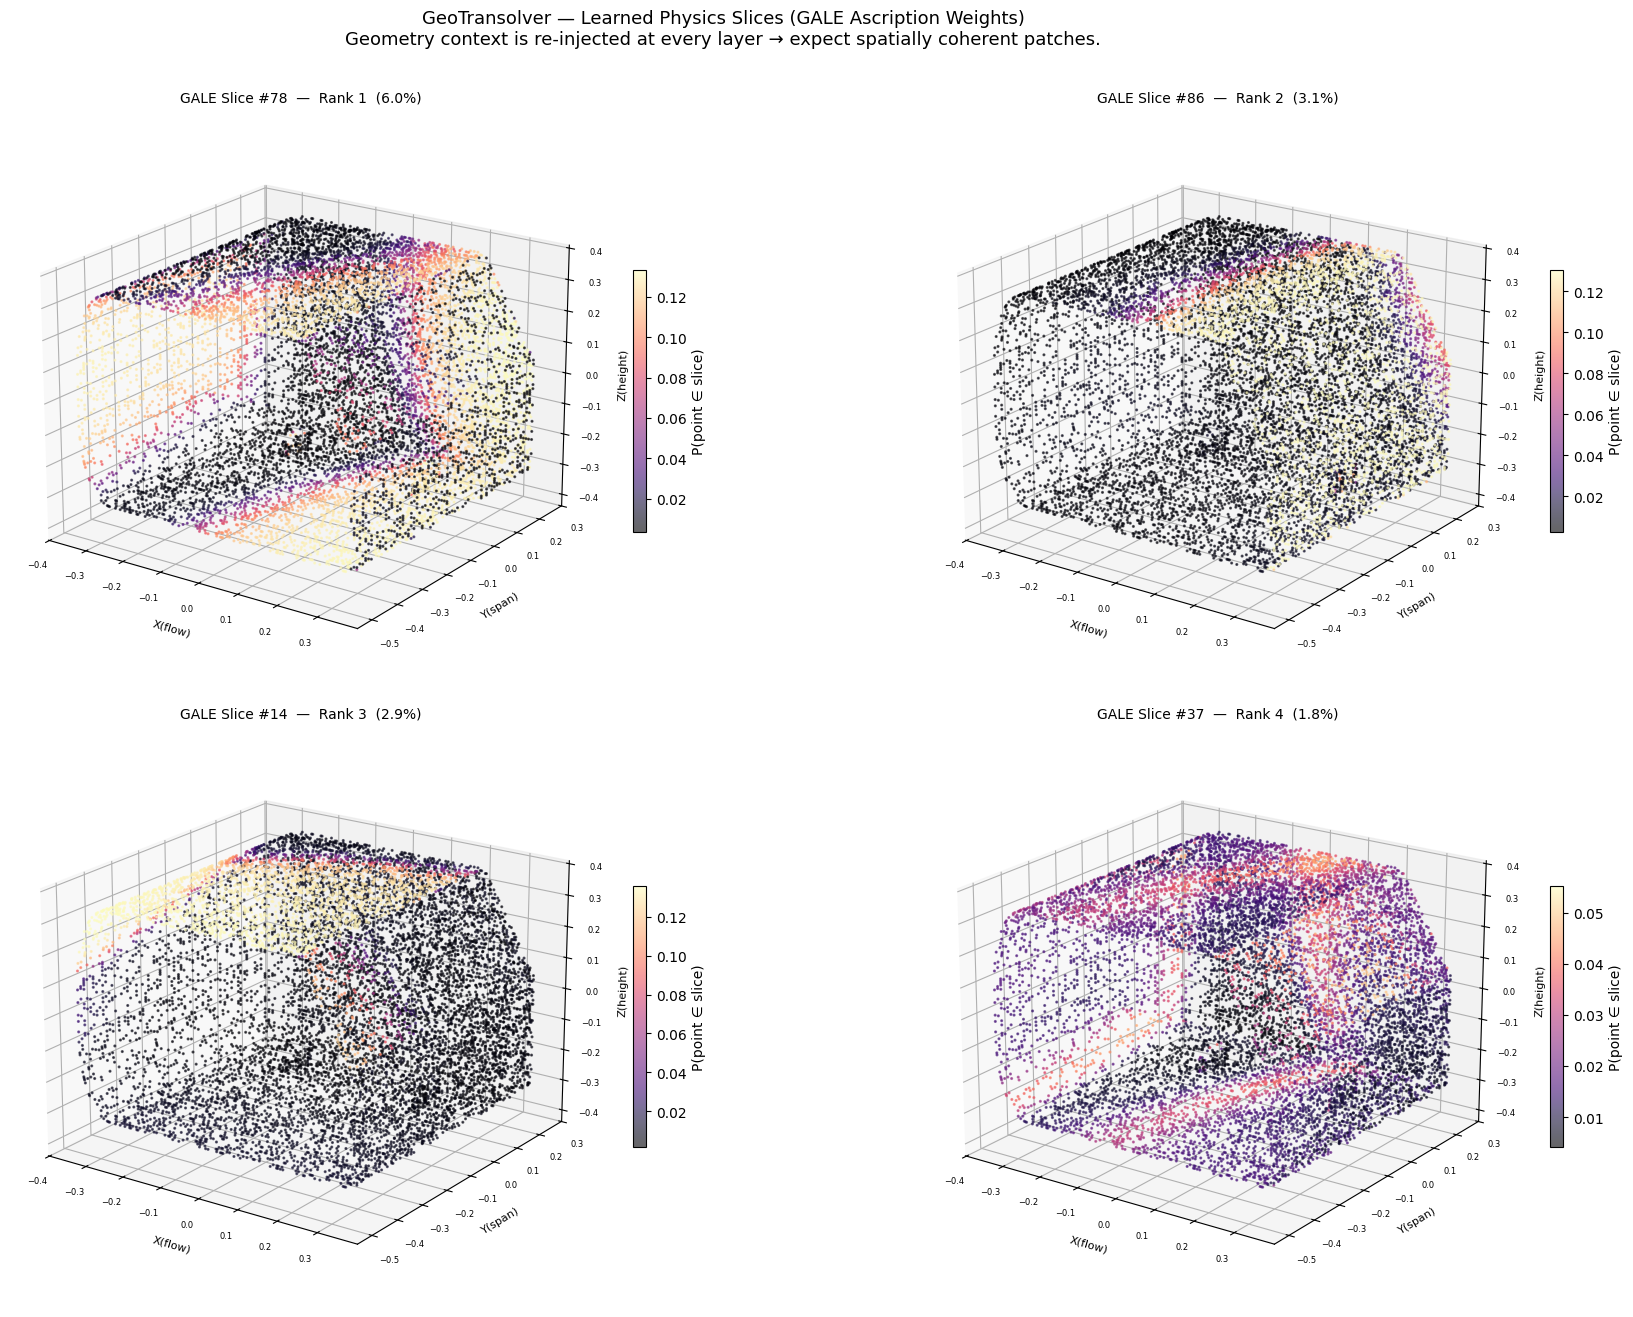

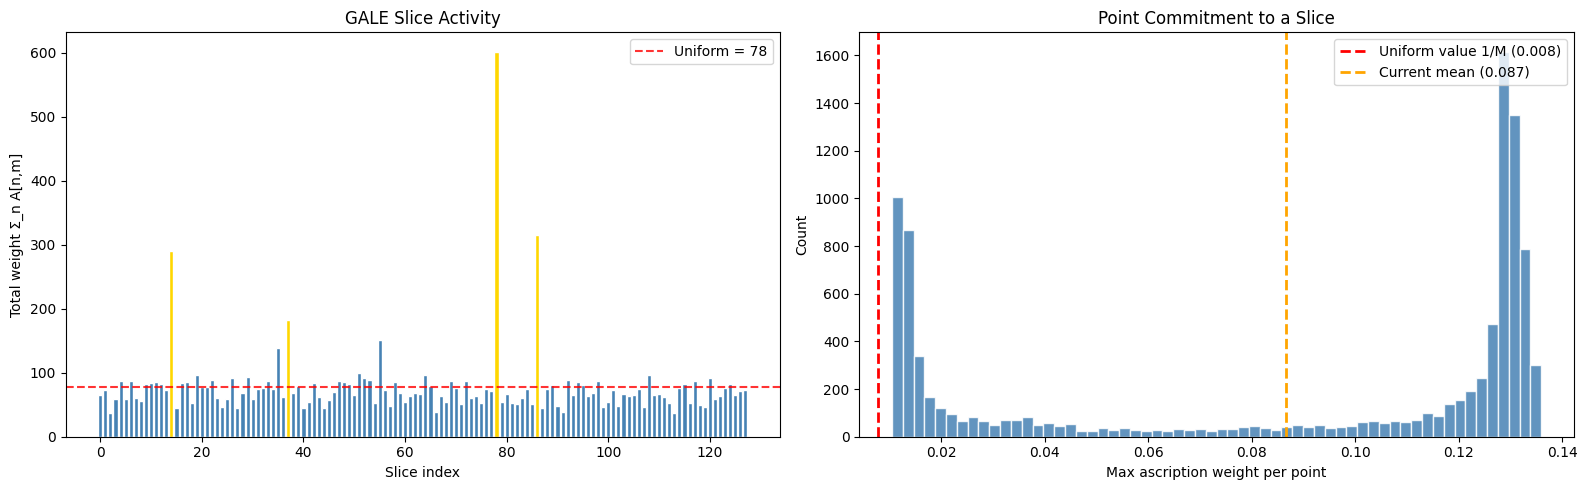

In [21]:
# ── GALE Ascription Weight Visualisation ──────────────────────────────────
# Uses a forward hook on geo_model.blocks[0].Attn.in_project_slice —
# the same robust approach as Notebook 3.  This captures the raw slice logits
# produced during the real forward pass, avoiding any need to manually
# reconstruct the hidden state via build_context / preprocess.
geo_model.eval()

# ── Step 1: Get a preprocessed validation sample ──────────────────────────────
sample          = val_datapipe[0]
embeddings      = sample["embeddings"].to(device)   # (1, N, 6)
geometry        = sample["geometry"].to(device)      # (1, M, 3)
features        = sample["fx"].to(device)            # (1, 1, 2)
local_positions = embeddings[:, :, :3]               # (1, N, 3)
coords_np       = embeddings[0, :, :3].cpu().numpy() # (N, 3) for plotting

# ── Step 2: Capture slice logits via a forward hook ───────────────────────────
# The hook fires on in_project_slice (the Linear that produces per-point slice
# logits) and saves its output without modifying the computation.
_captured = {}
def _hook(module, inp, out):
    _captured["slice_logits"] = out.detach()

hook = geo_model.blocks[0].Attn.in_project_slice.register_forward_hook(_hook)

with torch.no_grad():
    _ = geo_model(
        global_embedding=features,        # (1, 1, 2)
        local_embedding=embeddings,       # (1, N, 6)
        geometry=geometry,                # (1, M, 3)
        local_positions=local_positions,  # (1, N, 3)
    )

hook.remove()

# ── Step 3: Convert logits → ascription matrix A ──────────────────────────────
# in_project_slice output: (1, N, H, M) or (1, N, M) depending on version.
# Squeeze batch dim, average heads if present, apply softmax over slice dim.
logits = _captured["slice_logits"].squeeze(0)   # (N, H, M) or (N, M)
if logits.dim() == 2:
    logits = logits.unsqueeze(1)                 # (N, 1, M)

# Apply the LEARNED, CLAMPED temperature the model actually uses. GALE computes
#     softmax(in_project_slice(x) / clamp(temperature, 0.5, 5))
# and the hook fires BEFORE that division. Section 9 does this; Section 8 used to
# skip it, so the two sections described different distributions. Note the clamp
# matters: temperature is initialised at exactly 0.5 and clamp zeroes the gradient
# outside the range, so a head can drift below 0.5 and stay there while the model
# keeps using 0.5.
_attn = geo_model.blocks[0].Attn
_tau_p = getattr(_attn, "temperature", None)
if _tau_p is not None:
    _tau = torch.clamp(_tau_p.detach(), min=0.5, max=5).reshape(-1)
    TAU_S8 = float(_tau.mean())
    logits = logits / (_tau.view(1, -1, 1).to(logits.device)
                       if _tau.numel() == logits.shape[1] else _tau[0].to(logits.device))
else:
    TAU_S8 = None

A_heads = torch.softmax(logits, dim=-1)          # (N, H, M) — what the model uses
A_np    = A_heads.mean(dim=1).cpu().numpy()      # (N, M) head-averaged, for MAPS only
print(f"Learned temperature tau : "
      + (f"{TAU_S8:.4f} (clamped to [0.5, 5])" if TAU_S8 is not None else "not found"))

# (an `ascription` alias used to live here; no downstream cell uses it)

N_pts, M_actual = A_np.shape
print(f"Ascription matrix A: {A_np.shape}  ({N_pts:,} points × {M_actual} slices)")
print(f"Row-sum check (should be 1.0): {A_np[0].sum():.6f}")

# ── Step 4: Rank slices by total weight ───────────────────────────────────────
slice_usage   = A_np.sum(axis=0)
uniform_usage = N_pts / M_actual
top_k         = 4
top_slices    = np.argsort(slice_usage)[-top_k:][::-1]

print(f"\nTop {top_k} slices (uniform baseline = {uniform_usage:.0f} pts/slice):")
for rank, m in enumerate(top_slices):
    pct = 100 * slice_usage[m] / slice_usage.sum()
    print(f"  Rank {rank+1}: Slice #{m:2d}  {pct:.1f}% of total weight")

# ── Step 5: 3D scatter plots of top 4 slices ──────────────────────────────────
fig = plt.figure(figsize=(20, 13))
fig.suptitle(
    "GeoTransolver — Learned Physics Slices (GALE Ascription Weights)\n"
    "Geometry context is re-injected at every layer → expect spatially coherent patches.",
    fontsize=13, y=1.01,
)
for rank, m in enumerate(top_slices):
    ax = fig.add_subplot(2, 2, rank + 1, projection="3d")
    w  = A_np[:, m]
    # Autoscale. A 0-based scale squashes an early-training spread of e.g.
    # 0.0166-0.0171 into one flat colour and hides structure that IS present.
    sc = ax.scatter(coords_np[:, 0], coords_np[:, 1], coords_np[:, 2],
                    c=w, cmap="magma", s=1.5, alpha=0.6, vmin=w.min(), vmax=w.max())
    fig.colorbar(sc, ax=ax, shrink=0.45, pad=0.04, label="P(point ∈ slice)")
    pct = 100 * slice_usage[m] / slice_usage.sum()
    ax.set_title(f"GALE Slice #{m}  —  Rank {rank+1}  ({pct:.1f}%)", fontsize=10)
    for lbl, fn in zip(["X(flow)", "Y(span)", "Z(height)"],
                       [ax.set_xlabel, ax.set_ylabel, ax.set_zlabel]):
        fn(lbl, fontsize=8)
    ax.view_init(elev=20, azim=-55)
    ax.tick_params(labelsize=6)

plt.tight_layout()
plt.savefig("gale_ascription_weights.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Step 6: Slice activity bar chart + point-commitment histogram ──────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
colors = ["gold" if i in top_slices else "steelblue" for i in range(M_actual)]
ax.bar(range(M_actual), slice_usage, color=colors, edgecolor="white")
ax.axhline(uniform_usage, color="red", ls="--", lw=1.5, alpha=0.8,
           label=f"Uniform = {uniform_usage:.0f}")
ax.set_xlabel("Slice index"); ax.set_ylabel("Total weight Σ_n A[n,m]")
ax.set_title("GALE Slice Activity"); ax.legend()

ax = axes[1]
max_w = A_np.max(axis=1)
ax.hist(max_w, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(1/M_actual, color="red", ls="--", lw=2,
           label=f"Uniform value 1/M ({1/M_actual:.3f})")
ax.axvline(max_w.mean(), color="orange", ls="--", lw=2,
           label=f"Current mean ({max_w.mean():.3f})")
ax.set_xlabel("Max ascription weight per point"); ax.set_ylabel("Count")
ax.set_title("Point Commitment to a Slice"); ax.legend()

plt.tight_layout()
plt.savefig("gale_slice_distribution.png", dpi=100, bbox_inches="tight")
plt.show()


### Figure Interpretation

Each sub-plot colours the Ahmed Body surface by how strongly the model assigns each point to a particular **learned physical slice**. On a trained model:

- **High-entropy, diffuse patterns** (points evenly spread across all slices) indicate the model is still in its early "exploration" phase.
- **Low-entropy, focused patterns** (sharp regions of high weight) indicate the model has learned to associate specific geometric regions with distinct physical phenomena — this is GALE working correctly.

The key difference from Notebook 3's visualisation: the geometry context is **re-injected at every layer**, so at equal training length the slice boundaries should be more geometrically coherent than a vanilla Transolver of the same training length.


---
## 9. Shannon Entropy Analysis — Quantifying Slice Commitment

The ascription-weight maps give a qualitative feel for the slices.
**Shannon entropy** turns that into a number — but it must be computed carefully,
and interpreted with the model's actual accuracy in mind.

### The metric

For a mesh point *n* with ascription vector $\mathbf{a}_n$ over $M$ slices:

$$
H_n = -\sum_{m=0}^{M-1} A_{n,m} \log_2 A_{n,m} \quad \text{[bits]}, \qquad
H_{\max} = \log_2 M
$$

### Three things that corrupt this measurement — all handled below

**1. The learned temperature.**
GALE computes slice weights as

$$
A = \mathrm{softmax}\!\left(\frac{\texttt{in\_project\_slice}(x)}{\tau}\right)
$$

where $\tau$ is a **learned** `nn.Parameter` (typically initialised near 0.5).
Our forward hook captures the *pre-temperature* logits. Applying a plain softmax
to them measures a distribution the model never uses. If $\tau < 1$ the true
weights are sharper — so ignoring $\tau$ **systematically overestimates entropy**.

**2. Averaging over attention heads.**
Computing `softmax → mean over H heads → entropy` is not the same as
`softmax → entropy → mean over heads`. By Jensen's inequality:

$$
H\!\left(\tfrac{1}{H}\textstyle\sum_h A^{(h)}\right) \;\ge\; \tfrac{1}{H}\textstyle\sum_h H\!\left(A^{(h)}\right)
$$

Eight heads each sharply committed to *different* slices average into a flat
mixture. The head-averaged entropy then looks near-maximal even though every
individual head is decisive. **Per-head entropy is the correct commitment measure.**

**3. Entropy saturates at large $M$.**
With $M = 128$, $H$ is dominated by the 127-element tail. A point placing
$13\times$ the uniform weight on its top slice still scores $\approx 3\%$
"certainty". The metric simply cannot report high certainty unless assignments
are near one-hot. We therefore also report two saturation-resistant statistics:

| Metric | Definition | Reads as |
|---|---|---|
| **Effective slices** | $2^{H}$ | "this point behaves like a mixture of *k* slices" |
| **Concentration ratio** | $\max_m A_{n,m} \big/ (1/M)$ | "top slice carries *k*× the uniform share" |

### ⚠ Low entropy is *not* a training objective

Nothing in the MSE loss rewards sharp slice assignments. A soft mixture is a
perfectly valid — often optimal — solution. A converged GeoTransolver with
excellent L2 error can and does sit near $H_{\max}$.

**Do not read high entropy as "undertrained."** Judge convergence by validation
loss and L2/R² metrics. Use entropy only to characterise *how* the model
organises the mesh, and compare it **across layers**, where the meaningful signal
lives: layer 0 sees barely-processed geometry, while deeper blocks typically
specialise. The layer sweep below is the most informative panel in this section.

Computing slice statistics across layers... done.

Slice Commitment Analysis — GeoTransolver
  Slices M              : 128
  H_max = log2(128)     : 7.0000 bits
  Attention heads       : 8
  Learned temperature τ : 0.5141   (sharpens vs naive softmax)

+-----------------+------------+-----------+-------------+---------------+------------+-------------+
|      Layer      | H per-head | certainty | eff. slices | top-1 vs unif | H head-avg | eff. slices |
+-----------------+------------+-----------+-------------+---------------+------------+-------------+
| block 0 (first) |   5.820    |   16.9%   |    56.5     |     17.2x     |   6.596    |    96.7     |
| block 10 (mid)  |   4.336    |   38.1%   |    20.2     |     41.3x     |   5.887    |    59.2     |
| block 19 (last) |   4.510    |   35.6%   |    22.8     |     28.3x     |   6.146    |    70.8     |
+-----------------+------------+-----------+-------------+---------------+------------+-------------+

  per-head  = softmax → entropy 

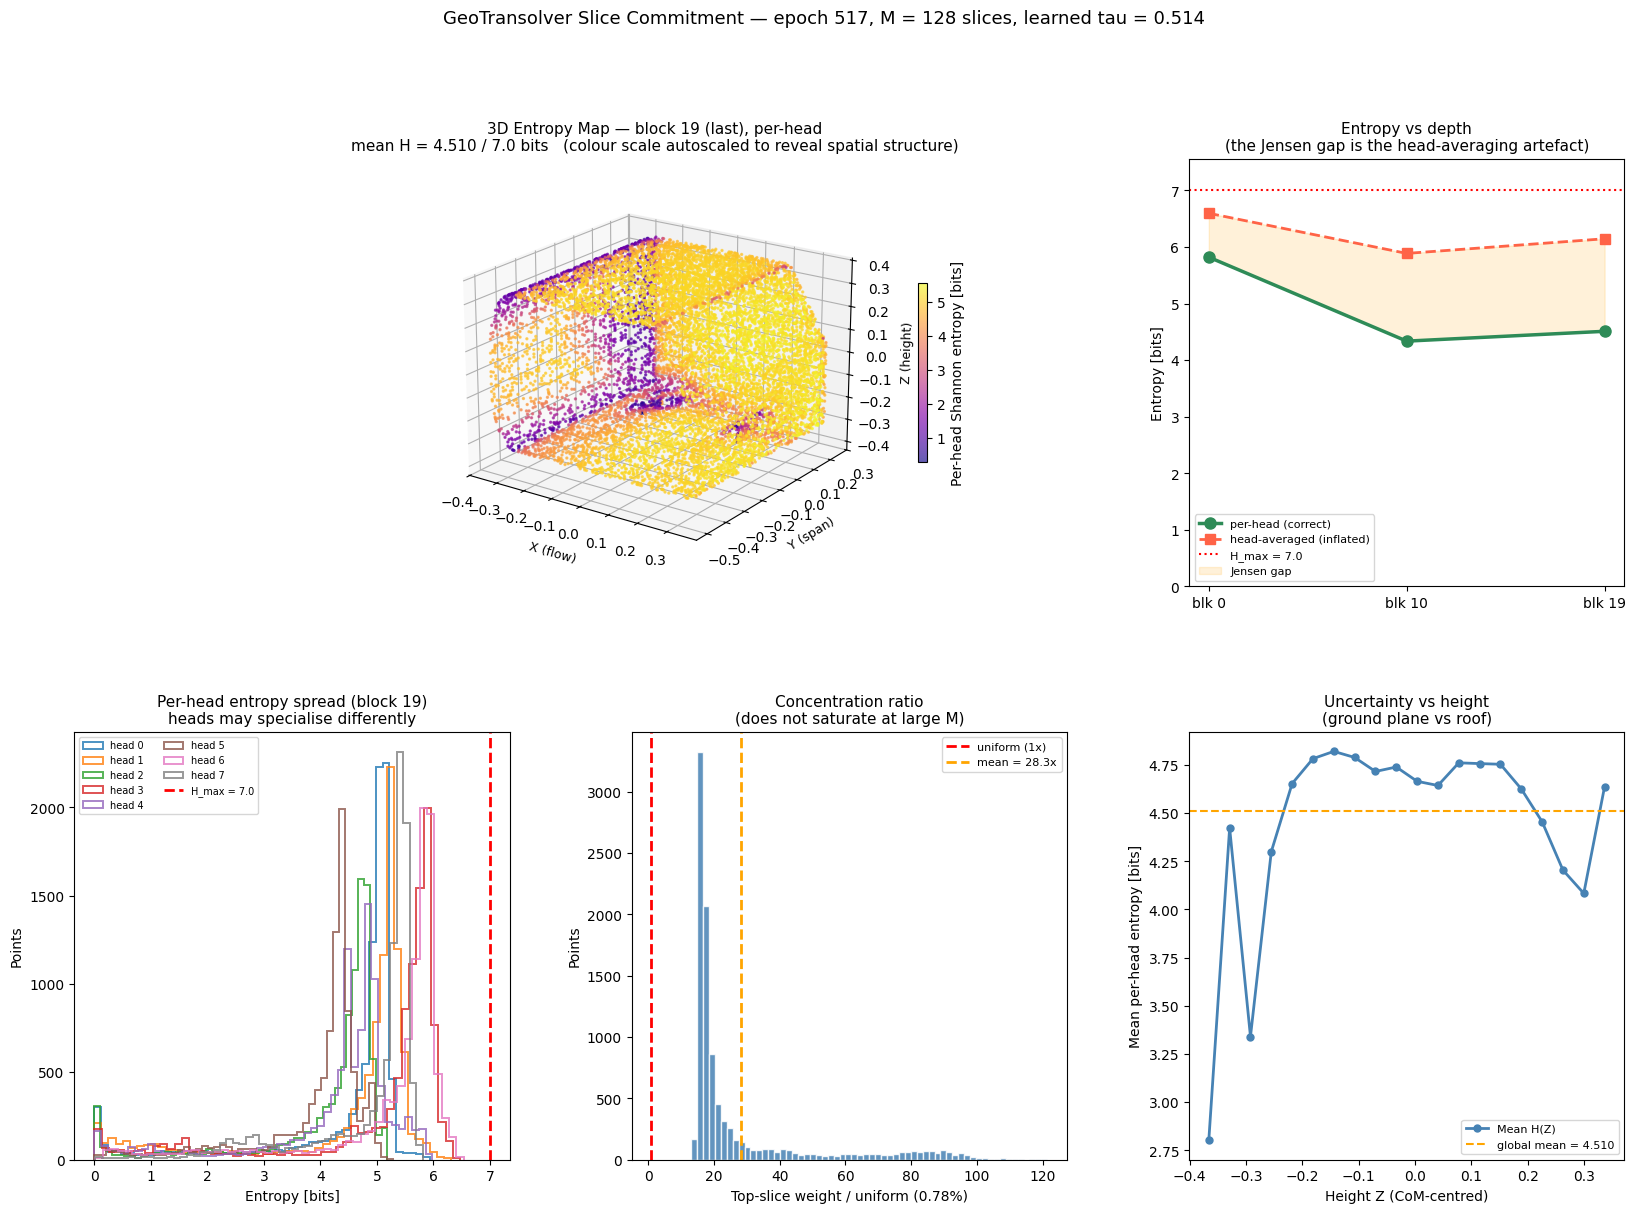


+-------------------------------+-------------------------------------+
|            Metric             |                Value                |
+-------------------------------+-------------------------------------+
|           Slices M            |                 128                 |
|             H_max             |             7.0000 bits             |
|    Learned temperature tau    |               0.5141                |
| Per-head entropy (last block) |             4.5100 bits             |
|     Head-averaged entropy     |             6.1456 bits             |
|     Jensen gap (artefact)     |             1.6355 bits             |
|  Effective slices per point   |             22.8 of 128             |
|    Top-slice concentration    |            28.3x uniform            |
|        Epochs trained         |                 517                 |
|            Verdict            | judge by val loss / L2, not entropy |
+-------------------------------+------------------------------

In [22]:
# ── Shannon Entropy Analysis (temperature-corrected, per-head, multi-layer) ───
# Fixes three measurement problems present in the naive version:
#   1. applies the LEARNED softmax temperature (hook sees pre-temperature logits)
#   2. reports per-head entropy, not entropy of the head-average
#   3. adds effective-slice-count and concentration ratio, which do not
#      saturate the way raw entropy does at M=128

eps = 1e-12


def slice_weights_for_block(block_idx: int):
    """
    Return (A_heads, A_mean, tau) for one GALE block.

      A_heads : (N, H, M) per-head ascription, temperature applied
      A_mean  : (N, M)    head-averaged ascription (what Section 8 plots)
      tau     : float or None — the learned temperature actually used
    """
    attn = geo_model.blocks[block_idx].Attn

    cap = {}
    h = attn.in_project_slice.register_forward_hook(
        lambda m, i, o: cap.__setitem__("logits", o.detach())
    )
    with torch.no_grad():
        _ = geo_model(
            global_embedding=features,
            local_embedding=embeddings,
            geometry=geometry,
            local_positions=local_positions,
        )
    h.remove()

    logits = cap["logits"].squeeze(0)          # (N, H, M) or (N, M)
    if logits.dim() == 2:                      # single head → add head axis
        logits = logits.unsqueeze(1)           # (N, 1, M)

    # ── Apply the LEARNED temperature ────────────────────────────────────────
    # GALE: softmax(in_project_slice(x) / temperature). The hook fires BEFORE
    # that division, so we must reproduce it or we measure the wrong distribution.
    tau_param = getattr(attn, "temperature", None)
    if tau_param is not None:
        # CLAMP to [0.5, 5] — physicsnemo does this before the softmax, and
        # temperature inits at exactly 0.5, so heads can sit below the bound.
        t = torch.clamp(tau_param.detach(), min=0.5, max=5).reshape(-1)
        tau_val = t.mean().item()
        if t.numel() == logits.shape[1]:
            logits = logits / t.view(1, -1, 1).to(logits.device)   # per-head tau
        else:
            logits = logits / t[0].to(logits.device)               # shared tau
    else:
        tau_val = None

    A_heads = torch.softmax(logits, dim=-1)    # (N, H, M)
    return A_heads.cpu().numpy(), A_heads.mean(dim=1).cpu().numpy(), tau_val


def entropy_stats(A_heads, A_mean, M):
    """Commitment statistics for one block."""
    H_max = np.log2(M)

    H_per_head = -np.sum(A_heads * np.log2(A_heads + eps), axis=2)   # (N, H)
    H_head     = H_per_head.mean()                                   # correct measure
    H_avg      = (-np.sum(A_mean * np.log2(A_mean + eps), axis=1)).mean()

    top_head = A_heads.max(axis=2).mean()      # mean top-1 weight, per head
    top_avg  = A_mean.max(axis=1).mean()

    return {
        "H_head":      H_head,
        "H_avg":       H_avg,
        "H_max":       H_max,
        "cert_head":   (1 - H_head / H_max) * 100,
        "cert_avg":    (1 - H_avg  / H_max) * 100,
        "eff_head":    2 ** H_head,
        "eff_avg":     2 ** H_avg,
        "conc_head":   top_head * M,           # ×uniform
        "conc_avg":    top_avg  * M,
        "H_per_head":  H_per_head,
    }


# ── Layer sweep: first / middle / last ────────────────────────────────────────
n_blocks   = len(geo_model.blocks)
sweep_idx  = sorted({0, n_blocks // 2, n_blocks - 1})
sweep      = {}

print("Computing slice statistics across layers...", end=" ", flush=True)
for b in sweep_idx:
    Ah, Am, tau = slice_weights_for_block(b)
    st = entropy_stats(Ah, Am, Ah.shape[2])
    st["tau"] = tau
    sweep[b] = st
print("done.\n")

M_used = list(sweep.values())[0]
H_max  = M_used["H_max"]
tau0   = sweep[sweep_idx[0]]["tau"]

print("=" * 78)
print("Slice Commitment Analysis — GeoTransolver")
print("=" * 78)
print(f"  Slices M              : {M_actual}")
print(f"  H_max = log2({M_actual})     : {H_max:.4f} bits")
print(f"  Attention heads       : {sweep[sweep_idx[0]]['H_per_head'].shape[1]}")
if tau0 is not None:
    print(f"  Learned temperature τ : {tau0:.4f}"
          f"   ({'sharpens' if tau0 < 1 else 'flattens'} vs naive softmax)")
else:
    print("  Learned temperature τ : not found on this module (none applied)")
print("=" * 78)

rows = []
for b in sweep_idx:
    s = sweep[b]
    label = f"block {b}" + (" (first)" if b == 0 else
                            " (last)"  if b == n_blocks - 1 else " (mid)")
    rows.append([
        label,
        f"{s['H_head']:.3f}",  f"{s['cert_head']:5.1f}%", f"{s['eff_head']:6.1f}",
        f"{s['conc_head']:5.1f}x",
        f"{s['H_avg']:.3f}",   f"{s['eff_avg']:6.1f}",
    ])

print()
print(tabulate(
    rows,
    headers=["Layer",
             "H per-head", "certainty", "eff. slices", "top-1 vs unif",
             "H head-avg", "eff. slices"],
    tablefmt="pretty"))
print()
print("  per-head  = softmax → entropy → mean over heads   ← CORRECT measure")
print("  head-avg  = softmax → mean over heads → entropy")
print("              (Section 8 plots this same head-averaged matrix)")
print("              (Jensen: head-avg is ALWAYS >= per-head)")

# ── Honest verdict ────────────────────────────────────────────────────────────
s_last  = sweep[sweep_idx[-1]]
s_first = sweep[sweep_idx[0]]
gap     = s_first["H_head"] - s_last["H_head"]

print()
print("─" * 78)
print("Interpretation")
print("─" * 78)
print("  Entropy is NOT a training objective. Nothing in the MSE loss rewards")
print("  sharp slice assignments — soft mixtures are a valid, often optimal")
print("  solution. Judge convergence by validation loss and L2/R2, not by H.")
print()
# Report the SHAPE of the profile, not just the endpoints. Comparing first to
# last hides a non-monotonic stack: if the minimum sits mid-network, "deeper
# blocks commit more strongly" is false for the deepest block.
_hs   = [sweep[b]["H_head"] for b in sweep_idx]
_imin = int(np.argmin(_hs))
_monotonic = all(a >= b for a, b in zip(_hs, _hs[1:])) or all(a <= b for a, b in zip(_hs, _hs[1:]))

print(f"  Depth profile: " + "  ".join(
    f"blk{b}={h:.3f}" for b, h in zip(sweep_idx, _hs)) + "  bits")
if abs(gap) < 0.05 and _monotonic:
    print(f"  Depth trend : flat ({gap:+.3f} bits first→last).")
    print("                All layers use a similarly soft partition.")
elif _monotonic and gap > 0:
    print(f"  Depth trend : MONOTONIC drop of {gap:.3f} bits, first to last.")
    print("                Commitment increases steadily with depth.")
elif _monotonic:
    print(f"  Depth trend : MONOTONIC rise of {-gap:.3f} bits, first to last.")
    print("                Later blocks spread weight more broadly.")
elif 0 < _imin < len(_hs) - 1:
    _rebound = _hs[-1] - _hs[_imin]
    print(f"  Depth trend : U-SHAPED. Minimum entropy at block "
          f"{sweep_idx[_imin]} ({_hs[_imin]:.3f} bits), then it RISES "
          f"{_rebound:.3f} bits by the last block.")
    print()
    print("                Note what this rules out: the deepest block is NOT the")
    print("                most committed one, so 'commitment grows with depth' is")
    print("                the wrong summary even though first > last.")
    print("                A plausible reading is that the middle of the stack does")
    print("                the sharpest slicing while the final blocks re-mix across")
    print("                states before the output projection — but this notebook")
    print("                measures three blocks, not twenty. Sweep every block")
    print("                before treating the shape as established.")
else:
    print(f"  Depth trend : non-monotonic, {gap:+.3f} bits net first→last.")
print()
print(f"  Concentration: top slice carries {s_last['conc_head']:.1f}x the uniform")
print(f"                 share ({100.0/M_actual:.2f}%) in the last block.")
# NOTE: 3x is NOT calibrated against random init. in_project_slice is initialised
# with torch.nn.init.orthogonal_, and a softmax over 128 near-Gaussian logits
# already has an expected max/uniform ratio well above 3. Treat these bands as
# rough guides; the defensible comparison is against an untrained model of the
# same shape, which this notebook does not build.
if s_last["conc_head"] > 3:
    print("                 -> Concentrated, but see the caveat above: this is not")
    print("                    measured against a random-init baseline.")
elif s_last["conc_head"] > 1.5:
    print("                 -> Mild but real structure.")
else:
    print("                 -> Close to uniform at the per-point level.")

# ═════════════════════════════════════════════════════════════════════════════
# FIGURES
# ═════════════════════════════════════════════════════════════════════════════
A_heads_last, A_mean_last, _ = slice_weights_for_block(sweep_idx[-1])
H_last = -np.sum(A_heads_last * np.log2(A_heads_last + eps), axis=2).mean(axis=1)  # (N,)

coords_ent = embeddings[0, :, :3].detach().cpu().numpy()
assert coords_ent.shape[0] == H_last.shape[0], "coords / entropy point mismatch"

fig = plt.figure(figsize=(20, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.34, wspace=0.28)

# ── Panel A: 3D entropy map (last block, per-head) ───────────────────────────
ax3d = fig.add_subplot(gs[0, :2], projection="3d")
sc = ax3d.scatter(coords_ent[:, 0], coords_ent[:, 1], coords_ent[:, 2],
                  c=H_last, cmap="plasma", s=2.0, alpha=0.65,
                  vmin=H_last.min(), vmax=H_last.max())
cb = fig.colorbar(sc, ax=ax3d, shrink=0.42, pad=0.05)
cb.set_label("Per-head Shannon entropy [bits]", fontsize=10)
ax3d.set_title(
    f"3D Entropy Map — block {sweep_idx[-1]} (last), per-head\n"
    f"mean H = {H_last.mean():.3f} / {H_max:.1f} bits   "
    f"(colour scale autoscaled to reveal spatial structure)",
    fontsize=11)
ax3d.set_xlabel("X (flow)", fontsize=9)
ax3d.set_ylabel("Y (span)", fontsize=9)
ax3d.set_zlabel("Z (height)", fontsize=9)
ax3d.view_init(elev=20, azim=-55)

# ── Panel B: entropy across layers, per-head vs head-averaged ────────────────
axL = fig.add_subplot(gs[0, 2])
xs  = np.arange(len(sweep_idx))
axL.plot(xs, [sweep[b]["H_head"] for b in sweep_idx], "o-",
         color="seagreen", lw=2.5, ms=8, label="per-head (correct)")
axL.plot(xs, [sweep[b]["H_avg"] for b in sweep_idx], "s--",
         color="tomato", lw=2, ms=7, label="head-averaged (inflated)")
axL.axhline(H_max, color="red", ls=":", lw=1.5, label=f"H_max = {H_max:.1f}")
axL.fill_between(xs,
                 [sweep[b]["H_head"] for b in sweep_idx],
                 [sweep[b]["H_avg"]  for b in sweep_idx],
                 color="orange", alpha=0.15, label="Jensen gap")
axL.set_xticks(xs); axL.set_xticklabels([f"blk {b}" for b in sweep_idx])
axL.set_ylabel("Entropy [bits]", fontsize=10)
axL.set_title("Entropy vs depth\n(the Jensen gap is the head-averaging artefact)",
              fontsize=11)
axL.set_ylim(0, H_max * 1.08)
axL.legend(fontsize=8, loc="lower left")

# ── Panel C: per-head entropy distribution, last block ───────────────────────
axH = fig.add_subplot(gs[1, 0])
Hph = -np.sum(A_heads_last * np.log2(A_heads_last + eps), axis=2)   # (N, H)
for h in range(Hph.shape[1]):
    axH.hist(Hph[:, h], bins=50, histtype="step", lw=1.4, alpha=0.8,
             label=f"head {h}" if Hph.shape[1] <= 8 else None)
axH.axvline(H_max, color="red", ls="--", lw=2, label=f"H_max = {H_max:.1f}")
axH.set_xlabel("Entropy [bits]", fontsize=10)
axH.set_ylabel("Points", fontsize=10)
axH.set_title(f"Per-head entropy spread (block {sweep_idx[-1]})\n"
              "heads may specialise differently", fontsize=11)
axH.legend(fontsize=7, ncol=2)

# ── Panel D: concentration ratio — saturation-resistant ──────────────────────
axC = fig.add_subplot(gs[1, 1])
conc = A_heads_last.max(axis=2).mean(axis=1) * M_actual   # (N,) x-uniform
axC.hist(conc, bins=60, color="steelblue", edgecolor="white", alpha=0.85)
axC.axvline(1.0, color="red", ls="--", lw=2, label="uniform (1x)")
axC.axvline(conc.mean(), color="orange", ls="--", lw=2,
            label=f"mean = {conc.mean():.1f}x")
axC.set_xlabel(f"Top-slice weight / uniform ({100.0/M_actual:.2f}%)", fontsize=10)
axC.set_ylabel("Points", fontsize=10)
axC.set_title("Concentration ratio\n(does not saturate at large M)", fontsize=11)
axC.legend(fontsize=8)

# ── Panel E: entropy vs height Z ─────────────────────────────────────────────
axZ = fig.add_subplot(gs[1, 2])
z_vals  = coords_ent[:, 2]
n_bins  = 20
z_edges = np.linspace(z_vals.min(), z_vals.max(), n_bins + 1)
ctrs    = 0.5 * (z_edges[:-1] + z_edges[1:])
dig     = np.clip(np.digitize(z_vals, z_edges) - 1, 0, n_bins - 1)
meanHz  = np.array([H_last[dig == k].mean() if (dig == k).any() else np.nan
                    for k in range(n_bins)])
axZ.plot(ctrs, meanHz, "o-", color="steelblue", lw=2, ms=5, label="Mean H(Z)")
axZ.axhline(H_last.mean(), color="orange", ls="--", lw=1.5,
            label=f"global mean = {H_last.mean():.3f}")
axZ.set_xlabel("Height Z (CoM-centred)", fontsize=10)
axZ.set_ylabel("Mean per-head entropy [bits]", fontsize=10)
axZ.set_title("Uncertainty vs height\n(ground plane vs roof)", fontsize=11)
axZ.legend(fontsize=8)

plt.suptitle(
    f"GeoTransolver Slice Commitment — epoch {start_epoch + NUM_EPOCHS}, "
    f"M = {M_actual} slices"
    + (f", learned tau = {tau0:.3f}" if tau0 is not None else ""),
    fontsize=13, y=0.995)
plt.savefig("gale_entropy_analysis.png", dpi=100, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
s = sweep[sweep_idx[-1]]
print()
print(tabulate([
    ["Slices M",                          f"{M_actual}"],
    ["H_max",                             f"{H_max:.4f} bits"],
    ["Learned temperature tau",           f"{tau0:.4f}" if tau0 is not None else "n/a"],
    ["Per-head entropy (last block)",     f"{s['H_head']:.4f} bits"],
    ["Head-averaged entropy",             f"{s['H_avg']:.4f} bits"],
    ["Jensen gap (artefact)",             f"{s['H_avg'] - s['H_head']:.4f} bits"],
    ["Effective slices per point",        f"{s['eff_head']:.1f} of {M_actual}"],
    ["Top-slice concentration",           f"{s['conc_head']:.1f}x uniform"],
    ["Epochs trained",                    f"{start_epoch + NUM_EPOCHS}"],
    ["Verdict",                           "judge by val loss / L2, not entropy"],
], headers=["Metric", "Value"], tablefmt="pretty"))


---
## 10. Summary

That completes the training half of the series. Notebook 6 adds uncertainty quantification.

### What we built

| Notebook | Takeaway |
|---|---|
| NB1 | Quadratic complexity $O(N^2)$ makes vanilla Transformers impractical for large meshes |
| NB2 | Physics-Attention reduces this to $O(N)$ by routing through $M \ll N$ physics slices |
| NB3 | `TransolverDataPipe` + Transolver trained end-to-end; `broadcast_global_features=True` |
| NB4 | GALE injects geometry context at every layer, preventing representation drift |
| NB5 | Same pipeline, `broadcast_global_features=False`, `include_geometry=True` → GeoTransolver |

### Shared pipeline — what changed between NB3 and NB5

```
TransolverDataPipe config:

  NB3 (Transolver)                       NB5 (GeoTransolver)
  broadcast_global_features = True       broadcast_global_features = False
  include_geometry = False               include_geometry = True

Resulting batch:

  batch["fx"]         (1, N, 2)          batch["fx"]         (1, 1, 2)
  batch["embeddings"] (1, N, 6)          batch["embeddings"] (1, N, 6)
  batch["fields"]     (1, N, 4)          batch["fields"]     (1, N, 4)
                                         batch["geometry"]   (1, M, 3)  ← new

Forward call:

  model(fx=…, embedding=…)               model(global_embedding=…,
                                               local_embedding=…,
                                               geometry=…,
                                               local_positions=…)
```

### Production vs. notebook

In production, model selection happens via Hydra YAML:
```
conf/model/transolver.yaml    → Transolver   (functional_dim: 2)
conf/model/geotransolver.yaml → GeoTransolver (functional_dim: 6, global_dim: 2, geometry_dim: 3)
```
The notebook uses the same class constructors directly with smaller dimensions for speed.

### Next steps
- Increase `NUM_POINTS`, `C_MODEL`, and `NUM_EPOCHS` toward production values.
- Enable `scale_invariance=True` (reference_scale from `core.yaml`) for car-size robustness.
- Run inference on a new geometry and compare Transolver vs. GeoTransolver predictions.